# Schritt 1: Klassifikation von Fashion-MNIST mit einem Dense-Netz und Hyperparameter-Tuning

In diesem Notebook untersuchen wir zwei Ansätze zur Klassifikation des Fashion-MNIST-Datensatzes:

1. ein einfaches Dense-Netz als Basismodell
2. eine automatische Hyperparametersuche mit KerasTuner

## Lernziele

Nach diesem Notebook sollten Sie:

- den Aufbau eines einfachen Dense-Netzes verstehen
- den Trainingsprozess mit Validierungsdaten und Early Stopping nachvollziehen können
- den Nutzen einer Hyperparameter-Optimierung verstehen
- Basismodell und optimiertes Modell vergleichen können

## Vorgehen

1. Fashion-MNIST laden und visualisieren
2. Daten skalieren und Validierungsset abtrennen
3. Basismodell definieren, trainieren und evaluieren
4. KerasTuner für die automatische Hyperparametersuche verwenden
5. Ergebnisse vergleichen und interpretieren

## Leitfragen (zum Nachdenken beim Durcharbeiten)

- Welche Test-Accuracy erreicht das Basismodell?
- Verbessert das KerasTuner-Tuning das Ergebnis – und wenn ja, um wie viel?
- Welche Hyperparameter wurden als beste gefunden – und warum könnten sie besser sein?
- Was fällt an der Konfusionsmatrix auf: Welche Klassen werden am häufigsten verwechselt?

# Schritt 2: Bibliotheken importieren

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Schritt 3: Fashion-MNIST laden
## Fashion-MNIST-Datensatz

Der Fashion-MNIST-Datensatz enthält:

- 60.000 Trainingsbilder
- 10.000 Testbilder
- Graustufenbilder mit 28 × 28 Pixeln
- 10 Klassen von Kleidungsstücken

Im Unterschied zu den handgeschriebenen Ziffern aus MNIST sind diese Klassen oft schwieriger zu unterscheiden.

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Trainingsdaten:", X_train_full.shape)
print("Testdaten:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainingsdaten: (60000, 28, 28)
Testdaten: (10000, 28, 28)


# Schritt 4: Klassennamen definieren
## Klassen des Fashion-MNIST-Datensatzes

Zur besseren Interpretation ordnen wir den numerischen Labels ihre Klassennamen zu.

In [3]:
class_names = [
    "T-Shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print(class_names)

['T-Shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


# Schritt 5: Erste Visualisierung
## Beispielbilder

Wir betrachten einige Beispiele aus dem Datensatz, um ein Gefühl für die Klassen zu bekommen.

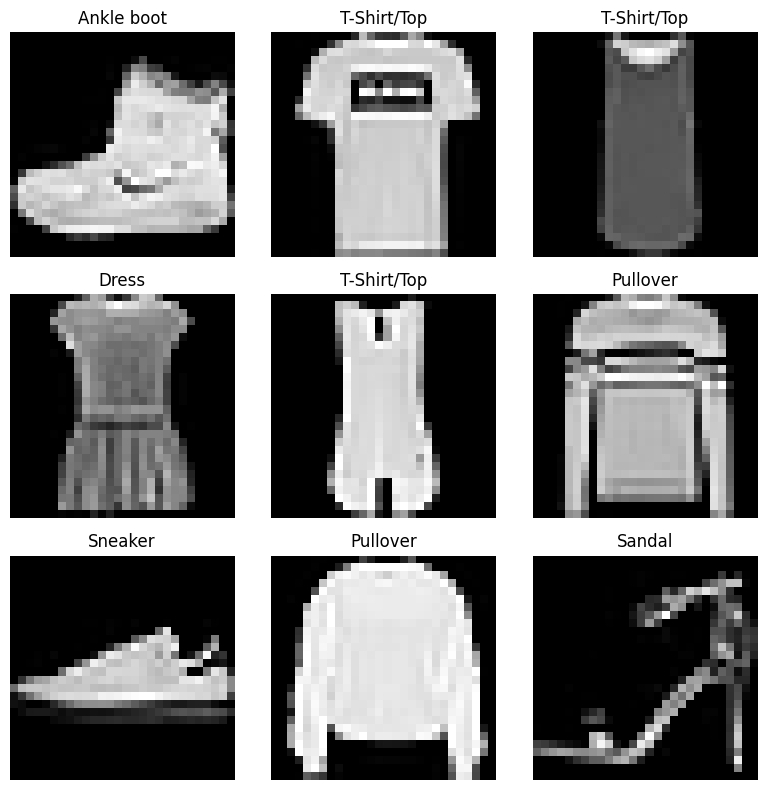

In [4]:
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Schritt 6: Skalierung der Daten
## Skalierung

Die Pixelwerte liegen im Bereich von 0 bis 255.

Für neuronale Netze ist es sinnvoll, diese Werte auf den Bereich [0,1] zu skalieren.

In [5]:
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Schritt 7: Validierungsset abtrennen
## Train-/Validierungs-Split

Wir trennen einen Teil der Trainingsdaten als Validierungsset ab.

Warum?

- um den Trainingsverlauf zu überwachen
- um Early Stopping korrekt anzuwenden
- um Hyperparameter auf separaten Daten zu bewerten

Die Testdaten bleiben bis zur finalen Evaluation unangetastet.

In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=5000, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Train: (55000, 28, 28)
Validation: (5000, 28, 28)
Test: (10000, 28, 28)


# Schritt 8: Basismodell (Dense-Netz mit einem Hidden Layer)
## Basismodell: einfaches Dense-Netz

Als ersten Ansatz verwenden wir ein einfaches neuronales Netz mit:

- `Flatten()`
- einem Hidden Layer
- einer Softmax-Ausgabe

Dieses Modell dient als **Baseline**.

Wichtig:
Das Modell ist einfach und schnell trainierbar, berücksichtigt aber keine räumliche Struktur der Bilder.

# Schritt 9: Basismodell definieren

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Schritt 10: Modellüberblick anzeigen
## Modellübersicht

Mit `model.summary()` können wir die Architektur und die Anzahl der Parameter betrachten.

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# Schritt 11: Modell kompilieren
## Kompilierung des Modells

Wir verwenden:

- `sparse_categorical_crossentropy` als Loss-Funktion
- `adam` als Optimizer
- `accuracy` als Metrik

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Schritt 12: Early Stopping definieren
## Early Stopping

Early Stopping beendet das Training automatisch, wenn sich die Leistung
auf den Validierungsdaten nicht weiter verbessert.

Wir überwachen hier:

- `val_loss`

Parameter:

- `monitor='val_loss'`
- `patience=3`
- `restore_best_weights=True`

Damit wird am Ende die beste Epoche verwendet.

In [11]:
def make_early_stop():
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

# Schritt 13: Basismodell trainieren
## Training des Basismodells

Wir trainieren das Modell auf den Trainingsdaten und überwachen die Leistung
auf dem Validierungsset.

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    callbacks=[make_early_stop()],
    verbose=1
)

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8228 - loss: 0.5051 - val_accuracy: 0.8506 - val_loss: 0.4226
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8626 - loss: 0.3810 - val_accuracy: 0.8704 - val_loss: 0.3688
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8759 - loss: 0.3400 - val_accuracy: 0.8738 - val_loss: 0.3522
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8848 - loss: 0.3120 - val_accuracy: 0.8716 - val_loss: 0.3632
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8912 - loss: 0.2973 - val_accuracy: 0.8732 - val_loss: 0.3558
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8941 - loss: 0.2813 - val_accuracy: 0.8798 - val_loss: 0.3349
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8993 - loss: 0.2686 - val_accuracy: 0.8630 - val_loss: 0.4114
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9043 - loss: 0.2579 - 

# Schritt 14: Lernkurven darstellen
## Lernkurven des Basismodells

Wir betrachten:

- Trainings-Loss und Validierungs-Loss
- Trainings-Accuracy und Validierungs-Accuracy

So können wir den Trainingsverlauf interpretieren und Overfitting erkennen.

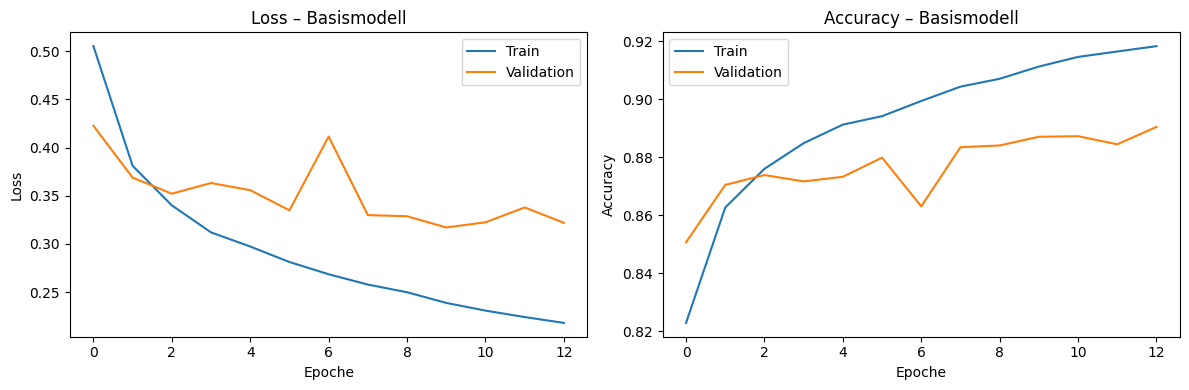

In [13]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss – Basismodell')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy – Basismodell')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Schritt 15: Basismodell evaluieren
## Evaluation des Basismodells

Zunächst betrachten wir die Leistung auf dem Validierungsset,
anschließend die finale Accuracy auf dem Testset.

In [14]:
val_loss, val_acc = model.evaluate(X_valid, y_valid, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Validation-Accuracy (Baseline):", val_acc)
print("Test-Accuracy (Baseline):", test_acc)

Validation-Accuracy (Baseline): 0.8870000243186951
Test-Accuracy (Baseline): 0.8837000131607056


# Schritt 16: Konfusionsmatrix des Basismodells
## Welche Klassen werden verwechselt?

Die Konfusionsmatrix zeigt, welche Klassen das Modell richtig erkennt
und wo es Fehler macht.

Fashion-MNIST ist besonders anspruchsvoll, weil sich mehrere Klassen
optisch ähneln – zum Beispiel **Pullover (Pullover), Hemd (Shirt) und Mantel (Coat)**.

Beobachtungsauftrag:
- Welche Klassen werden am häufigsten verwechselt?
- Ist das Ergebnis mit Ihren Erwartungen vereinbar?

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


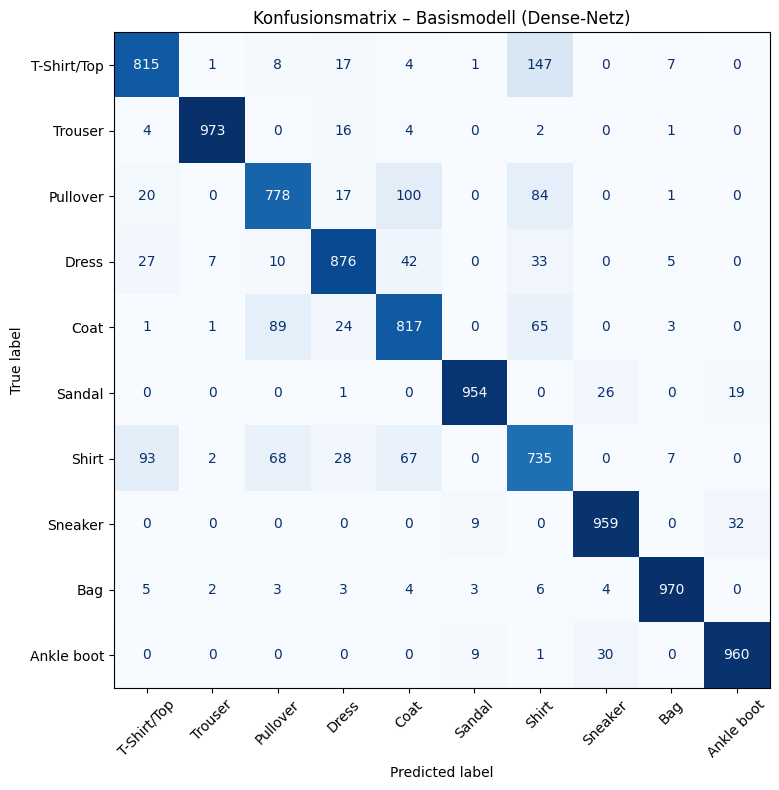

In [15]:
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title("Konfusionsmatrix – Basismodell (Dense-Netz)")
plt.tight_layout()
plt.show()

# Schritt 17: Kurze Interpretation des Basismodells
## Zwischenfazit zum Basismodell

Typischerweise erreicht das einfache Dense-Netz auf Fashion-MNIST
eine Test-Accuracy im Bereich von etwa **0.86 bis 0.89**.

Das Modell liefert damit eine brauchbare Baseline, ist aber noch nicht optimal.

Die Konfusionsmatrix zeigt die typischen Schwachstellen:
ähnlich aussehende Klassen wie Pullover, Hemd und Mantel werden häufiger verwechselt.

# Schritt 18: KerasTuner motivieren
## Automatische Hyperparameter-Optimierung mit KerasTuner

Bisher haben wir ein einfaches Dense-Netz mit fest gewählten Hyperparametern verwendet.

Nun wollen wir untersuchen:

- ob sich die Modellleistung durch Hyperparameter-Tuning verbessern lässt
- welche Kombination von Hyperparametern am besten funktioniert

Typische Hyperparameter sind zum Beispiel:

- Anzahl der Neuronen im Hidden Layer
- Lernrate des Optimizers

# Schritt 19: Installationshinweis für KerasTuner
## Hinweis zu KerasTuner

Falls `keras-tuner` in der aktuellen Umgebung noch nicht installiert ist,
kann es mit folgendem Befehl installiert werden:

`pip install keras-tuner`

In Google Colab ist dies manchmal notwendig.

In [16]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.2 MB/s eta 0:00:00


# Schritt 20: KerasTuner importieren

In [17]:
import keras_tuner as kt

# Schritt 21: Suchraum definieren
## Suchraum für die Hyperparameter

Wir variieren in diesem Beispiel zwei Hyperparameter:

- `units`: Anzahl der Neuronen im Hidden Layer
- `learning_rate`: Lernrate des Adam-Optimizers

Der Suchraum bleibt bewusst klein und übersichtlich, damit die Ergebnisse gut nachvollziehbar bleiben.

# Schritt 22: Funktion zum Erzeugen eines Modells
## Modellfunktion für den Tuner

KerasTuner benötigt eine Funktion, die anhand vorgeschlagener Hyperparameter
ein Modell erzeugt.

Der Tuner testet dann automatisch verschiedene Kombinationen.

In [18]:
def build_model(hp):
    units = hp.Choice('units', values=[64, 128, 256])
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(units, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Schritt 23: Tuner definieren
## Random Search mit KerasTuner

Wir verwenden hier `RandomSearch`.

Der Tuner probiert dabei verschiedene Kombinationen der Hyperparameter aus
und bewertet sie anhand der Validierungsleistung.

In [19]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=6,
    overwrite=True,
    directory='keras_tuner_dir',
    project_name='fashion_mnist_dense'
)

# Schritt 24: Suchraum anzeigen

In [20]:
tuner.search_space_summary()

Search space summary
Default search space size: 2
units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


# Schritt 25: Early Stopping auch für den Tuner verwenden
## Early Stopping beim Tuning

Auch während der Hyperparametersuche verwenden wir Early Stopping,
damit schlecht laufende Modelle nicht unnötig lange trainiert werden.

# Schritt 26: Tuner starten
## Start der Hyperparametersuche

Der Tuner trainiert nun mehrere Modellvarianten und vergleicht deren
Validierungs-Accuracy.

In [21]:
tuner.search(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    callbacks=[make_early_stop()],
    verbose=1
)

Trial 6 Complete [00h 01m 19s]
val_accuracy: 0.8605999946594238

Best val_accuracy So Far: 0.8894000053405762
Total elapsed time: 00h 08m 20s


# Schritt 27: Ergebnisse des Tuners zusammenfassen

In [ ]:
tuner.results_summary()

# Schritt 28: Beste Hyperparameter auslesen
## Beste gefundene Hyperparameter

Nun lesen wir die beste vom Tuner gefundene Kombination aus.

In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Beste Hyperparameter:")
print("units =", best_hp.get('units'))
print("learning_rate =", best_hp.get('learning_rate'))

# Schritt 29: Bestes Modell erzeugen
## Bestes Modell erzeugen

Mit den besten Hyperparametern erzeugen wir nun das optimierte Modell.

In [ ]:
best_model = tuner.hypermodel.build(best_hp)

# Schritt 30: Bestes Modell trainieren
## Training des optimierten Modells

Das optimierte Modell wird nun nochmals sauber trainiert,
damit wir es anschließend mit dem Basismodell vergleichen können.

Early Stopping beendet das Training automatisch, sobald sich der Validierungs-Loss
nicht weiter verbessert – die Epoche, bei der gestoppt wird, kann variieren.

In [ ]:
history_best = best_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    callbacks=[make_early_stop()],
    verbose=1
)

# Schritt 31: Lernkurven des optimierten Modells
## Vergleich der Lernkurven

Wir betrachten die Lernkurven des optimierten Modells und vergleichen sie
mit denen des Basismodells (Schritt 14).

Leitfragen:
- Zeigt das optimierte Modell eine schnellere Konvergenz?
- Ist ein Unterschied im Overfitting-Verhalten sichtbar?

In [ ]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_best.history['loss'], label='Train')
plt.plot(history_best.history['val_loss'], label='Validation')
plt.title('Loss – Optimiertes Modell')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_best.history['accuracy'], label='Train')
plt.plot(history_best.history['val_accuracy'], label='Validation')
plt.title('Accuracy – Optimiertes Modell')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Schritt 32: Optimiertes Modell evaluieren
## Evaluation des optimierten Modells

Nun messen wir die Accuracy des optimierten Modells auf Validierungs- und Testdaten.

In [ ]:
best_val_loss, best_val_acc = best_model.evaluate(X_valid, y_valid, verbose=0)
best_test_loss, best_test_acc = best_model.evaluate(X_test, y_test, verbose=0)

print("Validation-Accuracy (Tuned):", best_val_acc)
print("Test-Accuracy (Tuned):", best_test_acc)

# Schritt 33: Verbesserung berechnen
## Vergleich: Basismodell vs. optimiertes Modell

Zum Schluss vergleichen wir die Test-Accuracy beider Modelle direkt.

In [ ]:
improvement = best_test_acc - test_acc

print("Test-Accuracy (Baseline):", test_acc)
print("Test-Accuracy (Tuned):", best_test_acc)
print(f"Verbesserung: {100 * improvement:.2f} Prozentpunkte")

# Schritt 34: Ergebnis interpretieren
## Interpretation der Ergebnisse

Typischerweise verbessert das Hyperparameter-Tuning die Test-Accuracy
gegenüber dem einfachen Basismodell leicht.

Wichtige Beobachtung:

- Die Verbesserung ist oft **messbar**, aber nicht unbedingt sehr groß.
- Hyperparameter-Tuning kann helfen, das Modell systematisch zu verbessern.
- Der zusätzliche Rechenaufwand muss gegen den erzielten Gewinn abgewogen werden.

# Schritt 35: Merksatz
## Merksatz

Das Dense-Netz erreicht auf Fashion-MNIST typischerweise ca. **88 % Test-Accuracy**.
Auch mit KerasTuner-Optimierung bleibt die Verbesserung meist gering –
Dense-Netze stoßen hier an ihre Grenzen, weil sie die räumliche Bildstruktur ignorieren.

**Mehr Schichten und mehr Parameter helfen hier kaum – ein CNN ist die bessere Lösung.**

Im nächsten Notebook (K10_03) vergleichen wir ein tieferes MLP mit SGD,
bevor wir in K10_04 mit einem CNN deutlich bessere Ergebnisse erzielen.